In [10]:
import numpy as np 
path = '/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs/'
e_scaling, e_shift = 0.06565926932648217, 6.6588702845000975
path_indices = '/home/riccardo/tmp/Data100/'
train_indices = np.genfromtxt(path_indices+'train_set_idxes.txt').astype(int)
valid_indices = np.genfromtxt(path_indices+'valid_set_idxes.txt').astype(int)
test_indices = np.genfromtxt(path_indices+'test_set_idxes.txt').astype(int)

In [11]:
from uncertainty_toolbox.metrics_calibration import (
    get_proportion_lists,
    get_proportion_lists_vectorized,
    adversarial_group_calibration,
    miscalibration_area,
    miscalibration_area_from_proportions,
)

def get_curve(y_pred, y_std, y_true):
    exp_proportions, obs_proportions, = get_proportion_lists_vectorized(
                y_pred, y_std, y_true, prop_type='interval')
    return exp_proportions, obs_proportions
     

/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//lrt_pred/runs/lrt_small_train_best_3/LRT_0_val.parquet
/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//fo_pred/runs/fo_small_train_best_2/FO_0_val.parquet
/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//rad_pred/runs/rad_small_train_best_0/RAD_0_val.parquet
/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//lrt_pred/runs/lrt_train_best_4/LRT_0_val.parquet
/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//fo_pred/runs/fo_train_best_3/FO_0_val.parquet
/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//rad_pred/runs/rad_train_best_4/RAD_0_val.parquet


/tmp/ipykernel_621571/2809616259.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_std[df_std['Size'] == size_label],
/tmp/ipykernel_621571/2809616259.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_std[df_std['Size'] == size_label],


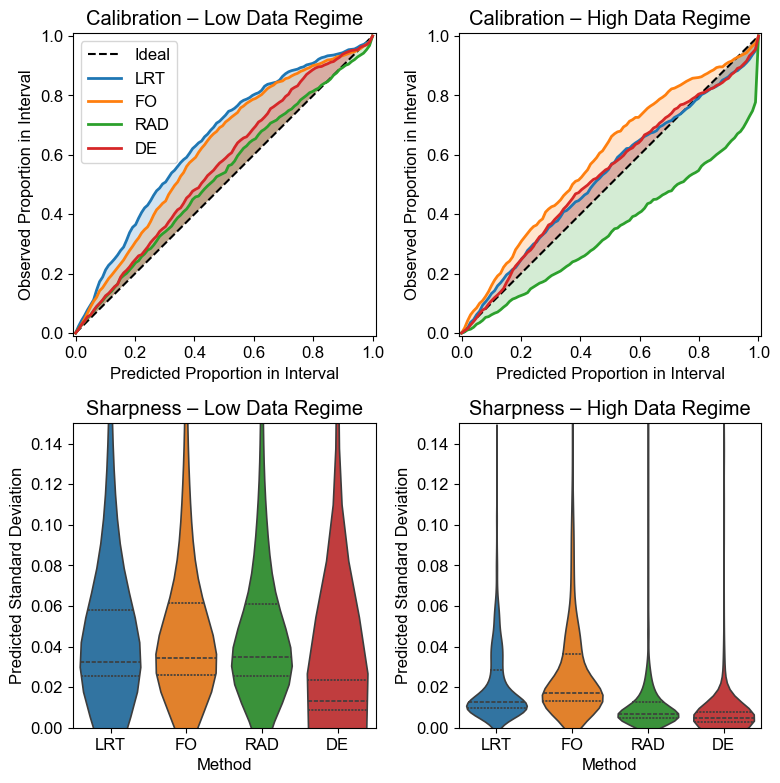

In [60]:
import uncertainty_toolbox as uct
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot style
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": "Arial",
    "font.size": 12,
    "mathtext.default": 'regular'
})

# Data definitions
big_data = [['lrt', '4'], ['fo', '3'], ['rad', '4'], ['de', '5']]
low_data = [['lrt', '3'], ['fo', '2'], ['rad', '0'], ['de', '3']]
size = [20, 100]  # example sizes for low/high

# Figure setup
fig, axes = plt.subplots(2, 2, figsize=(8, 8), sharey=False)
calib_ax = axes[0]
violin_ax = axes[1]
std_data = []

# Loop over data regimes
for i, data_regime in enumerate([low_data, big_data]):
    calib_ax[i].plot([0, 1], [0, 1], "--",color = 'black', label="Ideal")
    for method, run in data_regime:
        if method == 'de':
            parquet_path = glob.glob(f"{path}/{method.upper()}/{method}_pred_{size[i]}_{run}/runs/2025-03*/*.parquet", recursive=True)
            y_preds = []
            indices = range(len(test_indices))
            for parquet in parquet_path:
                rs = pd.read_csv(parquet)
                n_atoms = rs['n_atoms'].to_numpy()[indices]
                y_true_all = (rs['true'].to_numpy()[indices]/e_scaling + n_atoms*e_shift)/n_atoms
                y_pred = (rs['preds'].to_numpy()[indices]/e_scaling + n_atoms*e_shift)/n_atoms
                y_preds.append(y_pred)
            y_pred_all = np.array(y_preds).mean(axis=0)
            y_std = np.std(y_preds, axis=0)
            y_pred = y_pred_all
            y_true = y_true_all
        else:
            sizea = 'small_' if i == 0 else ''
            file_path = f'{path}/{method}_pred/runs/{method}_{sizea}train_best_{run}/{method.upper()}_0_val.parquet'
            print(file_path)
            rs = pd.read_csv(file_path)
            indices = test_indices
            n_atoms = rs['n_atoms'].to_numpy()[indices]
            y_true = (rs['true'].to_numpy()[indices] / e_scaling + n_atoms * e_shift) / n_atoms
            y_pred = (rs['preds'].to_numpy()[indices] / e_scaling + n_atoms * e_shift) / n_atoms
            y_std = (rs['stds'].to_numpy()[indices] / e_scaling) / n_atoms

        # Append stds for violin plots
        std_data.append(pd.DataFrame({
            'std': y_std,
            'Method': method.upper(),
            'Size': 'Low' if i == 0 else 'High'
        }))

        # Calibration curve
        exp_proportions, obs_proportions = get_curve(y_pred, y_std, y_true)
        calib_ax[i].plot(exp_proportions, obs_proportions, label=f"{method.upper()}", linewidth=2)
        calib_ax[i].fill_between(exp_proportions, exp_proportions, obs_proportions, alpha=0.2)
        calib_ax[i].set_xlabel("Predicted Proportion in Interval")
        calib_ax[i].set_ylabel("Observed Proportion in Interval")
        calib_ax[i].set_title("Calibration – Low Data Regime" if i == 0 else "Calibration – High Data Regime")
        calib_ax[i].axis("square")
        calib_ax[i].set_xlim(-0.01, 1.01)
        calib_ax[i].set_ylim(-0.01, 1.01)
        calib_ax[0].legend()
color_map = {
    'LRT': 'tab:blue',
    'FO': 'tab:orange',
    'RAD': 'tab:green',
    'DE': 'tab:red'
}
# Combine std data
df_std = pd.concat(std_data, ignore_index=True)
sns.color_palette("tab10", n_colors=len(df_std['Method'].unique()))
# Violin plots for sharpness
for i, size_label in enumerate(['Low', 'High']):
    subset = df_std[df_std['Size'] == size_label]
    methods_present = subset['Method'].unique()
    palette = {m: color_map[m] for m in methods_present}
    
    
    sns.violinplot(data=df_std[df_std['Size'] == size_label],
                   x='Method', y='std', ax=violin_ax[i],
                   inner='quartile', linewidth=1.2,
                   palette=palette)
    violin_ax[i].set_title(f"Sharpness – {size_label} Data Regime")
    violin_ax[i].set_xlabel("Method")
    violin_ax[i].set_ylabel("Predicted Standard Deviation")
    violin_ax[i].set_ylim(0, 0.15)

fig.tight_layout()
plt.show()
fig.savefig('cal_sharp.png', dpi=200)

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for i, size_label in enumerate(['Low', 'High']):
    subset = df_std[df_std['Size'] == size_label]
    methods_present = subset['Method'].unique()
    palette = {m: color_map[m] for m in methods_present}

    # Violin plot on one side (simulate one-sided with scale='width')
    sns.violinplot(
        data=subset,
        x='Method', y='std',
        ax=violin_ax[i],
        palette=palette,
        inner='quartile',
        linewidth=1.2,
        scale='width',
        cut=0
    )

    # Overlay scatter points shifted slightly to the right
    for j, method in enumerate(methods_present):
        method_data = subset[subset['Method'] == method]['std']
        x_vals = np.full(len(method_data), j) + 0.15  # shift right by 0.15
        violin_ax[i].scatter(x_vals, method_data, 
                             color=palette[method], alpha=0.6, s=10, edgecolor='black', linewidth=0.3)

    violin_ax[i].set_title(f"Sharpness – {size_label} Data Regime")
    violin_ax[i].set_xlabel("Method")
    violin_ax[i].set_ylabel("Predicted Standard Deviation")
    violin_ax[i].set_ylim(0, 0.3)


/tmp/ipykernel_621571/1327216433.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_621571/1327216433.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_621571/1327216433.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_621571/1327216433.py:11: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


/tmp/ipykernel_621571/297052273.py:28: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, bw_adjust=0.5, ax=ax, fill=True,
/tmp/ipykernel_621571/297052273.py:28: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, bw_adjust=0.5, ax=ax, fill=True,
/tmp/ipykernel_621571/297052273.py:28: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, bw_adjust=0.5, ax=ax, fill=True,
/tmp/ipykernel_621571/297052273.py:28: UserWarning: 

The `vertical` parameter is deprecated; assigning data to `y`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data, bw_adjust=0.5, ax=ax, fill=True,
/tmp/ipykernel_621571/297052273.

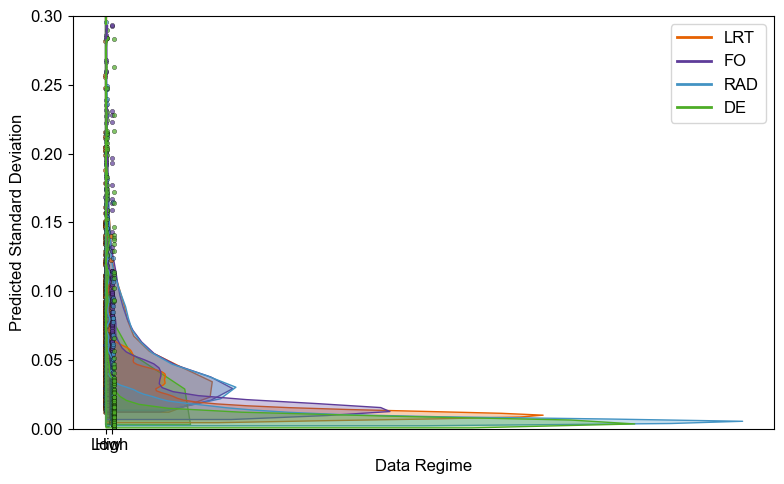

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample data: adapt this to your real data
# Must contain 'Group', 'Method', and 'std' columns
df_std['Group'] = df_std['Size']  # You can use Size or define a new category

# Setup
methods_order = ['LRT', 'FO', 'RAD', 'DE']
group_order = ['Low', 'High']
palette = {'LRT': '#E66101', 'FO': '#5E3C99', 'RAD': '#4393C3', 'DE': '#4DAC26'}

fig, ax = plt.subplots(figsize=(8, 5))

# Plot per group
for i, group in enumerate(group_order):
    for j, method in enumerate(methods_order):
        data = df_std[(df_std['Group'] == group) & (df_std['Method'] == method)]['std']
        if len(data) == 0:
            continue
        
        # Position for this group/method
        x = i + j * 0.15 - 0.225  # spread around the center i
        
        # Half violin: use kdeplot and clip left half
        sns.kdeplot(data, bw_adjust=0.5, ax=ax, fill=True,
                    clip=(data.min(), data.max()),
                    linewidth=1, color=palette[method],
                    alpha=0.3,
                    bw_method='scott',
                    gridsize=100,
                    cut=0,
                    vertical=True)
        
        # Overlay scatter
        y = data.values
        x_vals = np.random.normal(loc=x + 0.075, scale=0.005, size=len(y))
        ax.scatter(x_vals, y, color=palette[method], alpha=0.7, s=10, edgecolor='k', linewidth=0.3)

# Styling
ax.set_xticks([0, 1])
ax.set_xticklabels(group_order)
ax.set_ylabel("Predicted Standard Deviation")
ax.set_xlabel("Data Regime")
ax.set_ylim(0, 0.3)
ax.legend(handles=[plt.Line2D([0], [0], color=palette[m], lw=2, label=m) for m in methods_order])
plt.tight_layout()
plt.show()


In [15]:
f"{path}/{method.upper()}/{method}_pred_{size[i]}_{run}/runs/2023*/*.parquet"
    

'/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//DE/de_pred_i_3/runs/2023*/*.parquet'

In [16]:
f'{path}/{method}_pred/runs/{method}_{size}train_best_{run}/{method.upper()}_0_val.parquet'

'/home/riccardo/tmp/final_figures/logs_copy/home/g15farris/bin/bayesaenet/bnn_aenet/logs//de_pred/runs/de_Hightrain_best_3/DE_0_val.parquet'